In [28]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stim
import sinter

REPO = "/Users/ycx0376/hbm/lattice_surgery/decoder-bench"
sys.path.insert(0, REPO + "/decoder_bench/ls_ckt_gen")

from circuit_zzxx import circuit as ls_circuit

def coord_union(mapping):
    return (
        set(mapping["data_coords"])
        | set(mapping["x_measure_coords"])
        | set(mapping["z_measure_coords"])
    )

def set_patch_noise(sim, coords, p):
    for coord in coords:
        for gate in sim.gates_1Q:
            sim.profile[coord]["error"][gate] = p
        for gate in sim.gates_2Q:
            sim.profile[coord]["error"][gate] = p
        for gate in sim.measures:
            sim.profile[coord]["error"][gate] = p


def build_ls_stim_circuit(distance, p_left, p_right, basis="Z", bridge_policy="max"):
    sim = ls_circuit(
        distance=distance,
        num_patches_x=20,
        num_patches_y=20,
        spacing=1,
        disable_noise=False,
        fixed_t1=25,
        fixed_t2=40,
        fixed_cnot_latency=50,
        fixed_measure_latency=600,
        fixed_cnot_noise=0.0,
        fixed_measure_noise=0.0,
        rounds_per_op=distance,
        idle_multiplier=1,
        basis=basis,
        ls_basis=basis,
        merge=True,
    )

    left = sim.map_qubit(0)
    right = sim.map_qubit(1)
    merged = sim.merge({0: left, 1: right})

    left_coords = coord_union(left)
    right_coords = coord_union(right)
    bridge_coords = coord_union(merged) - left_coords - right_coords

    if bridge_policy == "max":
        p_bridge = max(p_left, p_right)
    elif bridge_policy == "mean":
        p_bridge = 0.5 * (p_left + p_right)
    elif bridge_policy == "left":
        p_bridge = p_left
    elif bridge_policy == "right":
        p_bridge = p_right
    else:
        raise ValueError("bridge_policy must be one of: max, mean, left, right")

    set_patch_noise(sim, left_coords, p_left)
    set_patch_noise(sim, right_coords, p_right)
    set_patch_noise(sim, bridge_coords, p_bridge)

    sim.from_string("qreg q[2];")

    # sim.ckt is the generated stim circuit text
    return stim.Circuit(sim.ckt)



def make_tasks(
    distances=(3, 5, 7, 9, 11),
    p_values=(1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3),
    basis="Z",
    right_factor=1.0,
):
    tasks = []
    for p in p_values:
        for d in distances:
            p_left = p
            p_right = right_factor * p

            if np.isclose(right_factor, 1.0):
                mode = "symmetric"
            elif np.isclose(right_factor, 5.0):
                mode = "asymmetric_5x"
            elif np.isclose(right_factor, 10.0):
                mode = "asymmetric_10x"
            else:
                mode = f"asymmetric_{right_factor:g}x"

            c = build_ls_stim_circuit(
                distance=d,
                p_left=p_left,
                p_right=p_right,
                basis=basis,
                bridge_policy="max",
            )

            tasks.append(
                sinter.Task(
                    circuit=c,
                    json_metadata={
                        "mode": mode,
                        "distance": d,
                        "p": p,
                        "p_left": p_left,
                        "p_right": p_right,
                        "right_factor": right_factor,
                    },
                )
            )
    return tasks


def collect_df(tasks, max_shots=20_000, max_errors=400):
    stats = sinter.collect(
        tasks=tasks,
        decoders=["pymatching"],
        max_shots=max_shots,
        max_errors=max_errors,
        num_workers=1,   # change if you want
    )

    rows = []
    for stat in stats:
        md = stat.json_metadata
        rows.append({
            "mode": md["mode"],
            "distance": md["distance"],
            "p": md["p"],
            "p_left": md["p_left"],
            "p_right": md["p_right"],
            "shots": stat.shots,
            "errors": stat.errors,
            "ler": stat.errors / stat.shots if stat.shots else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["mode", "distance", "p"])


In [29]:
distances = [3, 5, 7, 9, 11]
p_values = [1e-4, 3e-4, 7e-4, 1e-3, 3e-3, 7e-3, 1e-2, 3e-2, 7e-2]

tasks_sym = make_tasks(distances=distances, p_values=p_values, right_factor=1.0)
tasks_5x  = make_tasks(distances=distances, p_values=p_values, right_factor=5.0)
tasks_10x = make_tasks(distances=distances, p_values=p_values, right_factor=10.0)

df_sym = collect_df(tasks_sym, max_shots=100_000, max_errors=2_000)
df_5x  = collect_df(tasks_5x,  max_shots=100_000, max_errors=2_000)
df_10x = collect_df(tasks_10x, max_shots=100_000, max_errors=2_000)

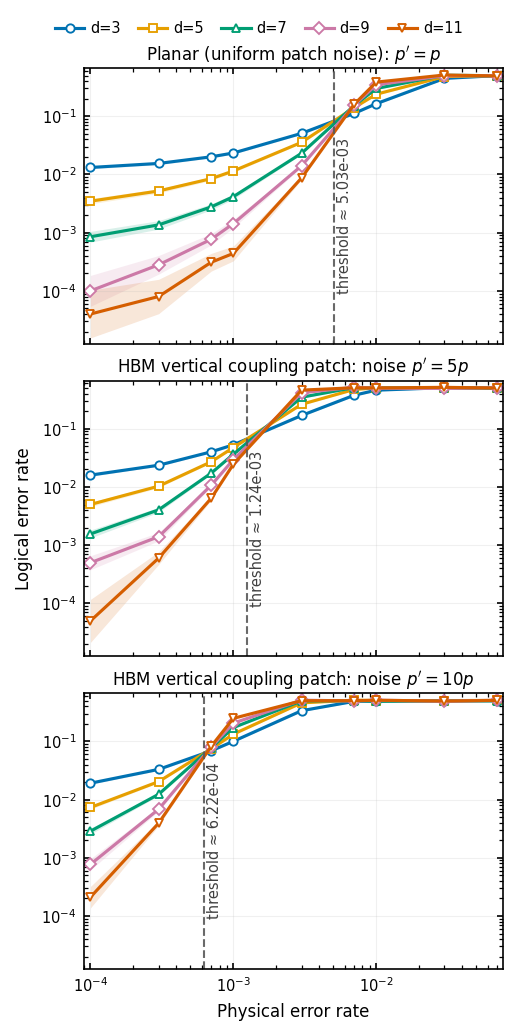

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def wilson_interval(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    lo = max(center - half, 1e-12)
    hi = min(center + half, 1.0)
    return lo, hi


def prepare_plot_df(df):
    g = (
        df.groupby(["mode", "distance", "p"], as_index=False)[["shots", "errors"]]
        .sum()
        .sort_values(["mode", "distance", "p"])
    )

    g["ler"] = g["errors"] / g["shots"]
    ci = np.array([wilson_interval(k, n) for k, n in zip(g["errors"], g["shots"])])
    g["ler_lo"] = ci[:, 0]
    g["ler_hi"] = ci[:, 1]
    return g


def set_publication_style():
    plt.rcdefaults()

    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "legend.frameon": False,
    })


def estimate_threshold(sub_df):
    """
    Estimate threshold from crossings between adjacent code-distance curves.
    Works in log-log space and returns the median crossing point.
    """
    distances = sorted(sub_df["distance"].unique())
    crossings = []

    for d1, d2 in zip(distances[:-1], distances[1:]):
        s1 = sub_df[sub_df["distance"] == d1][["p", "ler"]].sort_values("p")
        s2 = sub_df[sub_df["distance"] == d2][["p", "ler"]].sort_values("p")

        merged = pd.merge(s1, s2, on="p", suffixes=("_1", "_2")).dropna()
        if len(merged) < 2:
            continue

        x = np.log10(merged["p"].to_numpy())
        ydiff = np.log10(merged["ler_1"].to_numpy()) - np.log10(merged["ler_2"].to_numpy())

        for i in range(len(x) - 1):
            y0, y1 = ydiff[i], ydiff[i + 1]

            if y0 == 0:
                crossings.append(10 ** x[i])
                continue

            if y0 * y1 < 0:
                # linear interpolation in log p
                xc = x[i] - y0 * (x[i + 1] - x[i]) / (y1 - y0)
                crossings.append(10 ** xc)

    if len(crossings) == 0:
        return None

    return float(np.min(crossings))


def plot_micro_ler(df, outname="ls_ler_micro"):
    set_publication_style()
    plot_df = prepare_plot_df(df)

    modes = ["symmetric", "asymmetric_5x", "asymmetric_10x"]
    title_map = {
        "symmetric": r"Planar (uniform patch noise): $p' = p$",
        "asymmetric_5x": r"HBM vertical coupling patch: noise $p' = 5p$",
        "asymmetric_10x": r"HBM vertical coupling patch: noise $p' = 10p$",
    }

    distances = sorted(plot_df["distance"].unique())

    color_map = {
        3: "#0072B2",
        5: "#E69F00",
        7: "#009E73",
        9: "#CC79A7",
        11: "#D55E00",
    }
    marker_map = {
        3: "o",
        5: "s",
        7: "^",
        9: "D",
        11: "v",
    }

    COLUMNWIDTH_PT = 241.14749
    fig_width = COLUMNWIDTH_PT / 72.27

    fig, axes = plt.subplots(
        3, 1,
        figsize=(fig_width, 6.6),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    y_positive = plot_df["ler_lo"][plot_df["ler_lo"] > 0]
    y_min = max(y_positive.min() * 0.8, 1e-6) if len(y_positive) else 1e-6
    y_max = min(plot_df["ler_hi"].max() * 1.25, 1.0)

    handles = []
    labels = []

    for ax, mode in zip(axes, modes):
        sub = plot_df[plot_df["mode"] == mode].copy()

        for d in distances:
            s = sub[sub["distance"] == d].sort_values("p")
            if s.empty:
                continue

            line, = ax.plot(
                s["p"],
                s["ler"],
                label=f"d={d}",
                color=color_map.get(d, None),
                marker=marker_map.get(d, "o"),
                markerfacecolor="white",
                markeredgewidth=0.9,
            )

            ax.fill_between(
                s["p"],
                s["ler_lo"],
                s["ler_hi"],
                color=line.get_color(),
                alpha=0.15,
                linewidth=0,
            )

            if mode == "symmetric":
                handles.append(line)
                labels.append(f"d={d}")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(sub["p"].min() * 0.9, sub["p"].max() * 1.1)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, which="major", alpha=0.18, linewidth=0.5)
        ax.tick_params(which="both", top=True, right=True)

        ax.set_title(title_map[mode], pad=4)

        threshold = estimate_threshold(sub)
        if threshold is not None:
            ax.axvline(
                threshold,
                linestyle="--",
                linewidth=1.0,
                color="0.35",
                alpha=0.9,
            )

            ax.text(
                threshold * 1.05,
                y_min * (y_max / y_min) ** 0.18,
                f"threshold ≈ {threshold:.2e}",
                rotation=90,
                va="bottom",
                ha="left",
                color="0.25",
                fontsize=7,
            )

    axes[1].set_ylabel("Logical error rate")
    axes[-1].set_xlabel("Physical error rate")

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, 1.03),
        columnspacing=1.2,
        handletextpad=0.4,
    )

    fig.savefig(f"{outname}.pdf", bbox_inches="tight", pad_inches=0, dpi=600)
    plt.show()


df_all = pd.concat([df_sym, df_5x, df_10x], ignore_index=True)
plot_micro_ler(df_all, outname="LS_vertical_interconnect")

In [ ]:
# COLUMNWIDTH = 241.14749pt
# TEXTWIDTH = 506.295pt